In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVR, OneClassSVM
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

In [8]:
data = pd.read_csv('../dataset/processed/battery_health_dataset.csv')

X = data[['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']]
y = data['SoH']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Initialize the model

data = pd.read_csv('../dataset/processed/battery_health_dataset.csv')

X = data[['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']]
y = data['SoH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


boosting_models = {
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)  # Suppress training output
}

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids
param_grids = {
    'Gradient Boosting': {
        'n_estimators': range(20,200,20),
        'learning_rate': [0.01, 0.1, 0.05],
        'max_depth': [3, 5]
    },
    'AdaBoost': {
        'n_estimators': range(20,200,20),
        'learning_rate': [0.01, 0.05, 0.1]
    },
    'LightGBM': {
        'n_estimators': range(20,200,20),
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': range(10,100,10)
    },
    'CatBoost': {
        'learning_rate': [0.01, 0.05, 0.1],
    }
}

In [ ]:
best_models = {}
best_params = {}
best_scores = {}

# Run GridSearchCV for each model
for model_name, model in boosting_models.items():
    print(f"Running GridSearchCV for {model_name}...")

    grid_search = GridSearchCV(
        model,
        param_grid=param_grids[model_name],
        cv=5,
        scoring='neg_root_mean_squared_error',  # RMSE as metric
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_
    best_scores[model_name] = -grid_search.best_score_
    best_params[model_name] = grid_search.best_params_

    print(f"Best {model_name}: {grid_search.best_params_}")
    print(f"Best RMSE: {best_scores[model_name]:.4f}\n")

Running GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 180}
Best RMSE: 1.6773

Running GridSearchCV for AdaBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best AdaBoost: {'learning_rate': 0.05, 'n_estimators': 100}
Best RMSE: 4.3546

Running GridSearchCV for LightGBM...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best LightGBM: {'learning_rate': 0.1, 'n_estimators': 180, 'num_leaves': 90}
Best RMSE: 1.2683

Running GridSearchCV for CatBoost...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
1 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\catboost\core.py", line 5873, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
  

Best CatBoost: {'learning_rate': 0.1}
Best RMSE: 1.3603



In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Store final results
final_results = {}

# Test each best model on the test set
for model_name, best_model in best_models.items():
    y_pred = best_model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    final_results[model_name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

# Display results
print(f"{'Model':<20}{'MAE':<10}{'RMSE':<10}{'R² Score':<10}")
print("="*50)
for model_name, metrics in final_results.items():
    print(f"{model_name:<20}{metrics['MAE']:<10.4f}{metrics['RMSE']:<10.4f}{metrics['R²']:<10.4f}")

Model               MAE       RMSE      R² Score  
Gradient Boosting   1.0337    1.7316    0.9401    
AdaBoost            3.4107    4.3551    0.6210    
LightGBM            0.6571    1.2544    0.9686    
CatBoost            0.8151    1.4108    0.9602    


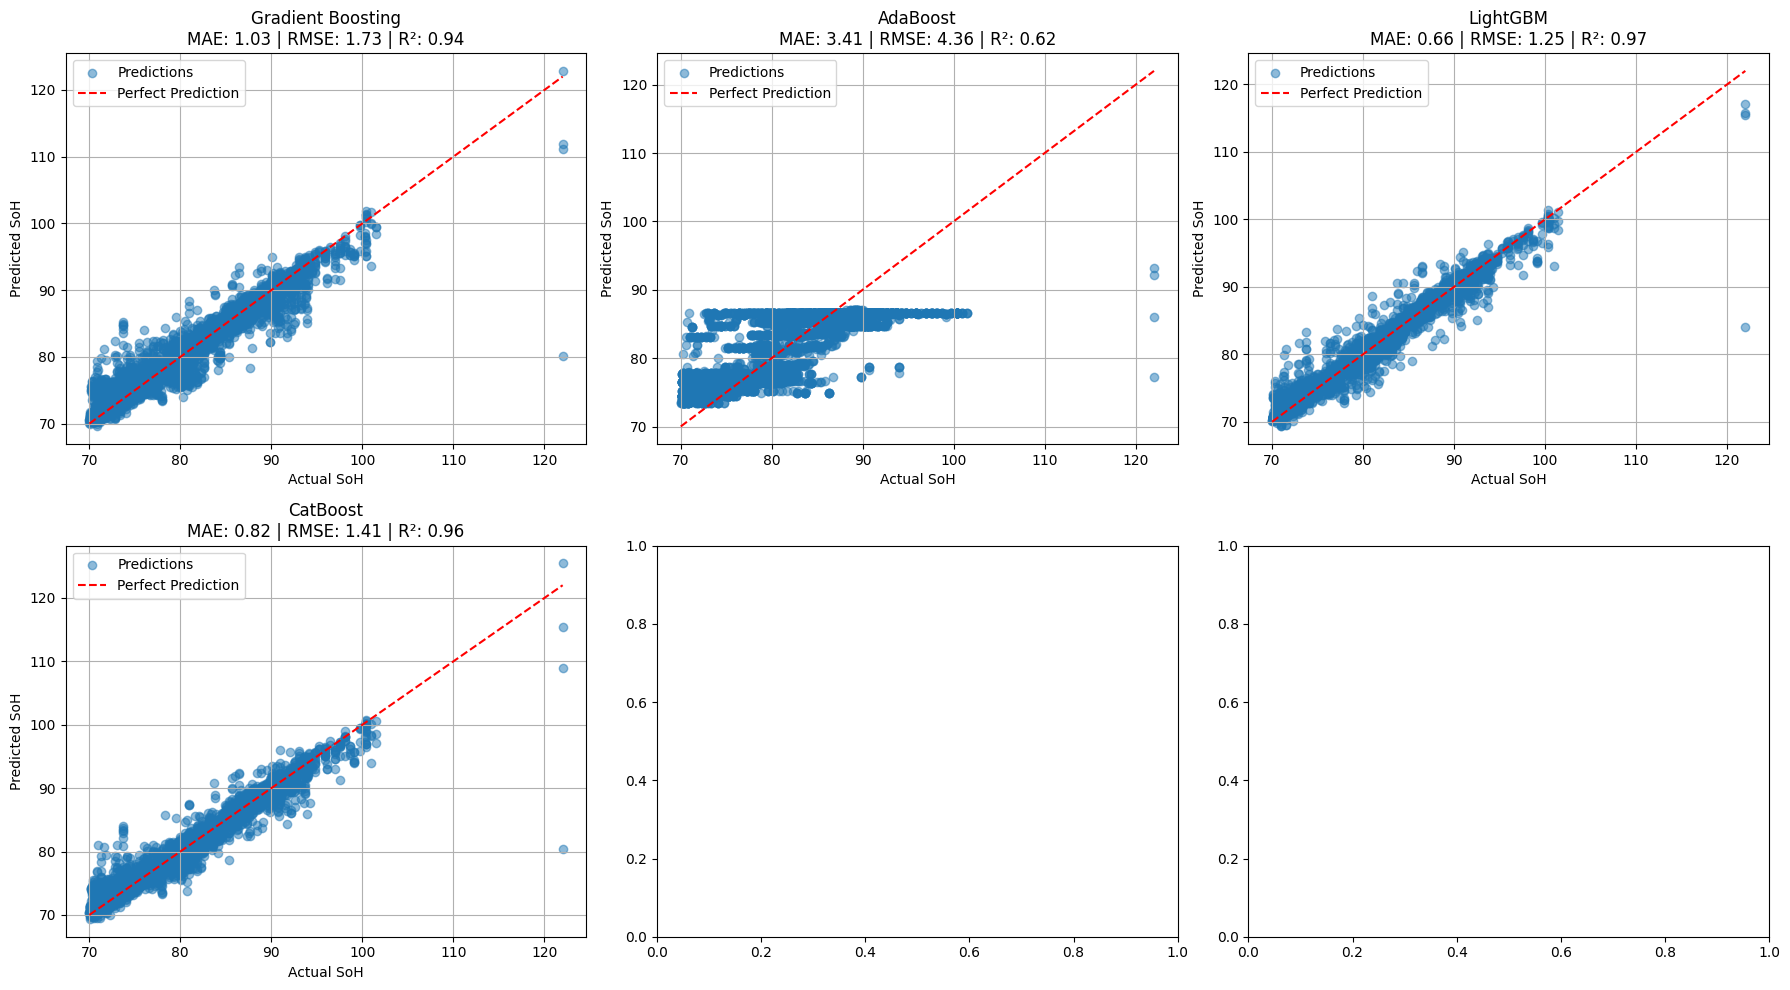

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (model_name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)

    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.5, label='Predictions')
    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
            color='red', linestyle='--', label='Perfect Prediction')

    ax.set_xlabel('Actual SoH')
    ax.set_ylabel('Predicted SoH')
    ax.set_title(f'{model_name}\nMAE: {final_results[model_name]["MAE"]:.2f} | '
                 f'RMSE: {final_results[model_name]["RMSE"]:.2f} | R²: {final_results[model_name]["R²"]:.2f}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()